In [7]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    display = print


sns.set_theme(style="whitegrid", context="talk")


def resolve_workspace_root():
    current = Path.cwd().resolve()
    candidates = [current, current.parent]
    for candidate in candidates:
        if (candidate / "outputs").exists() and (candidate / "New_files").exists():
            return candidate
    return current


WORKSPACE_ROOT = resolve_workspace_root()
SNELLIUS_ROOT = WORKSPACE_ROOT / "outputs" / "Snellius_run_1"
DEFAULT_SELECTED_RUNS = ["run_1", "run_2", "run_3"]
DEFAULT_SELECTED_MODELS = None
COMPARISONS = {
    "Ground truth to GNN": ("target_class", "gnn_pred"),
    "Ground truth to LLM": ("target_class", "llm_pred_parsed"),
    "LLM relative to GNN": ("gnn_pred", "llm_pred_parsed"),
}
METRIC_ORDER = [
    "accuracy",
    "mean_accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "mcc",
    "coverage",
]
DISPLAY_NAMES = {
    "accuracy": "Accuracy",
    "mean_accuracy": "Mean accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "specificity": "Specificity",
    "mcc": "MCC",
    "coverage": "Coverage",
}


In [8]:
def parse_binary_label(value):
    if value is None:
        return None
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, (int, np.integer)):
        value = int(value)
        return value if value in (0, 1) else None
    if isinstance(value, (float, np.floating)):
        if float(value).is_integer():
            value = int(value)
            return value if value in (0, 1) else None
        return None

    text = str(value).strip()
    if not text or text.lower() == "unknown":
        return None

    match = re.search(r"predicted\s+class\s+is\s+([01])\b", text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    if text in {"0", "1"}:
        return int(text)

    if re.fullmatch(r"[01](?:\.0+)?", text):
        return int(float(text))

    return None


def list_run_dirs(snellius_root):
    run_dirs = []
    if not snellius_root.exists():
        return run_dirs
    for model_dir in sorted(path for path in snellius_root.iterdir() if path.is_dir()):
        for run_dir in sorted(path for path in model_dir.iterdir() if path.is_dir() and path.name.startswith("run_")):
            run_dirs.append(run_dir)
    return run_dirs


def load_run_results(run_dir):
    raw_path = run_dir / "results_raw.json"
    if not raw_path.exists():
        return pd.DataFrame()

    records = pd.read_json(raw_path)
    records = records.copy()
    records["run"] = run_dir.name
    records["model_name"] = run_dir.parent.name
    records["llm_pred_parsed"] = records["llm_pred"].map(parse_binary_label)
    records["target_class"] = records["target_class"].map(parse_binary_label)
    records["gnn_pred"] = records["gnn_pred"].map(parse_binary_label)
    return records


def load_selected_runs(snellius_root, selected_runs=None, selected_models=None):
    run_dirs = list_run_dirs(snellius_root)
    if selected_runs is not None:
        selected_runs = set(selected_runs)
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.name in selected_runs]
    if selected_models is not None:
        selected_models = set(selected_models)
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.parent.name in selected_models]

    frames = [load_run_results(run_dir) for run_dir in run_dirs]
    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        return pd.DataFrame()

    combined = pd.concat(frames, ignore_index=True)
    combined["model_name"] = pd.Categorical(
        combined["model_name"],
        categories=sorted(combined["model_name"].dropna().unique()),
        ordered=True,
    )
    combined["run"] = pd.Categorical(
        combined["run"],
        categories=sorted(combined["run"].dropna().unique()),
        ordered=True,
    )
    return combined


## Helpers

In [9]:
def confusion_counts(y_true, y_pred):
    tp = tn = fp = fn = 0
    valid = 0
    for truth, pred in zip(y_true, y_pred):
        if truth not in (0, 1) or pred not in (0, 1):
            continue
        valid += 1
        if truth == 1 and pred == 1:
            tp += 1
        elif truth == 0 and pred == 0:
            tn += 1
        elif truth == 0 and pred == 1:
            fp += 1
        elif truth == 1 and pred == 0:
            fn += 1
    return tp, tn, fp, fn, valid


def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compute_binary_metrics(y_true, y_pred, total_count=None):
    tp, tn, fp, fn, valid_count = confusion_counts(y_true, y_pred)
    if total_count is None:
        total_count = len(y_true)

    accuracy = safe_divide(tp + tn, valid_count)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    if np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0:
        f1 = np.nan
    else:
        f1 = 2 * precision * recall / (precision + recall)
    if np.isnan(recall) or np.isnan(specificity):
        mean_accuracy = np.nan
    else:
        mean_accuracy = (recall + specificity) / 2

    denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    if denominator == 0:
        mcc = np.nan
    else:
        mcc = ((tp * tn) - (fp * fn)) / denominator

    return {
        "accuracy": accuracy,
        "mean_accuracy": mean_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "mcc": mcc,
        "coverage": safe_divide(valid_count, total_count),
        "valid_predictions": valid_count,
        "total_samples": total_count,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def build_metrics_frame(results_df):
    rows = []
    if results_df.empty:
        return pd.DataFrame()

    for (run_name, model_name), group in results_df.groupby(["run", "model_name"], sort=True, observed=False):
        for comparison_name, (truth_col, pred_col) in COMPARISONS.items():
            metrics = compute_binary_metrics(
                group[truth_col].tolist(),
                group[pred_col].tolist(),
                total_count=len(group),
            )
            for metric_name in METRIC_ORDER:
                rows.append(
                    {
                        "run": run_name,
                        "model_name": model_name,
                        "comparison": comparison_name,
                        "metric": metric_name,
                        "value": metrics[metric_name],
                    }
                )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "valid_predictions",
                    "value": metrics["valid_predictions"],
                }
            )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "total_samples",
                    "value": metrics["total_samples"],
                }
            )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "tp",
                    "value": metrics["tp"],
                }
            )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "tn",
                    "value": metrics["tn"],
                }
            )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "fp",
                    "value": metrics["fp"],
                }
            )
            rows.append(
                {
                    "run": run_name,
                    "model_name": model_name,
                    "comparison": comparison_name,
                    "metric": "fn",
                    "value": metrics["fn"],
                }
            )
    return pd.DataFrame(rows)


## Metrics

In [10]:
def plot_metric_panels(metrics_df, comparison_name, selected_runs, selected_models=None, save_dir=None):
    plot_df = metrics_df[metrics_df["comparison"] == comparison_name].copy()
    plot_df = plot_df[plot_df["metric"].isin(METRIC_ORDER)]

    if selected_models is not None:
        selected_models = list(selected_models)
        plot_df = plot_df[plot_df["model_name"].isin(selected_models)]

    plot_df["metric"] = pd.Categorical(plot_df["metric"], categories=METRIC_ORDER, ordered=True)
    plot_df["run"] = pd.Categorical(plot_df["run"], categories=selected_runs, ordered=True)
    plot_df = plot_df.sort_values(["metric", "model_name", "run"])

    columns = 3
    rows = math.ceil(len(METRIC_ORDER) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(18, 5 * rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for index, metric_name in enumerate(METRIC_ORDER):
        axis = axes[index]
        subset = plot_df[plot_df["metric"] == metric_name]
        if subset.empty:
            axis.set_axis_off()
            continue

        subset = subset.copy()
        subset["value"] = subset["value"].fillna(0.0)

        sns.barplot(
            data=subset,
            x="model_name",
            y="value",
            hue="run",
            hue_order=selected_runs,
            ax=axis,
        )
        axis.set_title(DISPLAY_NAMES[metric_name])
        axis.set_xlabel("")
        axis.set_ylabel("Score")
        axis.tick_params(axis="x", rotation=35)

        if metric_name == "mcc":
            axis.set_ylim(-1.05, 1.05)
        else:
            axis.set_ylim(0, 1.05)

        if index == 0:
            axis.legend(title="Run", loc="best")
        else:
            legend = axis.get_legend()
            if legend is not None:
                legend.remove()

    for axis in axes[len(METRIC_ORDER):]:
        axis.set_axis_off()

    fig.suptitle(comparison_name, y=1.02, fontsize=18)
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        figure_name = comparison_name.lower().replace(" ", "_").replace("->", "to")
        fig.savefig(save_dir / f"{figure_name}.png", dpi=200, bbox_inches="tight")

    return fig


In [ ]:
def plot_metrics_split_by_model(metrics_df, comparison_name, selected_runs, selected_models=None, save_dir=None, figsize_per=(4,4)):
    df = metrics_df[(metrics_df["comparison"] == comparison_name) & (metrics_df["metric"].isin(METRIC_ORDER))].copy()
    if selected_models is not None:
        df = df[df["model_name"].isin(selected_models)]

    models = sorted(df["model_name"].dropna().unique())
    figs = []
    for model in models:
        subset = df[df["model_name"] == model]
        if subset.empty:
            continue
        subset = subset.copy()
        subset["run"] = pd.Categorical(subset["run"], categories=selected_runs, ordered=True)
        subset = subset.sort_values(["metric", "run"])

        columns = 3
        rows = math.ceil(len(METRIC_ORDER) / columns)
        fig, axes = plt.subplots(rows, columns, figsize=(columns * figsize_per[0], rows * figsize_per[1]), squeeze=False)
        axes = np.array(axes).reshape(-1)

        for idx, metric_name in enumerate(METRIC_ORDER):
            ax = axes[idx]
            vals = subset[subset["metric"] == metric_name][["run", "value"]]
            if vals.empty:
                ax.set_axis_off()
                continue

            # ensure rows for all runs (so bars align)
            plot_df = pd.DataFrame({"run": list(selected_runs)})
            plot_df = plot_df.merge(vals, on="run", how="left")
            plot_df["value"] = plot_df["value"].fillna(0.0)

            sns.barplot(data=plot_df, x="run", y="value", order=selected_runs, ax=ax)
            ax.set_title(DISPLAY_NAMES.get(metric_name, metric_name))
            ax.set_xlabel("")
            ax.set_ylabel("Score")
            ax.tick_params(axis="x", rotation=35)
            if metric_name == "mcc":
                ax.set_ylim(-1.05, 1.05)
            else:
                ax.set_ylim(0, 1.05)

        for a in axes[len(METRIC_ORDER):]:
            a.set_axis_off()

        fig.suptitle(f"{model} — {comparison_name}", y=1.02, fontsize=14)
        fig.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_name = f"{model}_{comparison_name}".lower().replace(" ", "_").replace("/", "_")
            fig.savefig(save_dir / f"{safe_name}.png", dpi=200, bbox_inches="tight")

        figs.append(fig)

    return figs


## Load and Plot

Loaded 3000 rows from 3 run(s) and 5 model(s).


metric,run,model_name,comparison,accuracy,coverage,f1,mcc,mean_accuracy,precision,recall,specificity
0,run_1,Qwen2.5-3B,Ground truth to GNN,0.965000,1.000,0.666667,0.656077,0.786348,0.777778,0.583333,0.989362
3,run_1,Qwen3.5-27B,Ground truth to GNN,0.970000,1.000,0.727273,0.714851,0.828014,0.800000,0.666667,0.989362
6,run_1,Qwen3.5-35B-A3B,Ground truth to GNN,0.960000,1.000,0.600000,0.593067,0.744681,0.750000,0.500000,0.989362
9,run_1,Qwen3.5-4B,Ground truth to GNN,0.960000,1.000,0.600000,0.593067,0.744681,0.750000,0.500000,0.989362
12,run_1,Qwen3.5-9B,Ground truth to GNN,0.955000,1.000,0.608696,0.585494,0.781028,0.636364,0.583333,0.978723
15,run_2,Qwen2.5-3B,Ground truth to GNN,0.965000,1.000,NaN,-0.017629,0.492347,0.000000,0.000000,0.984694
18,run_2,Qwen3.5-27B,Ground truth to GNN,0.970000,1.000,NaN,-0.014358,0.494898,0.000000,0.000000,0.989796
21,run_2,Qwen3.5-35B-A3B,Ground truth to GNN,0.970000,1.000,NaN,-0.014358,0.494898,0.000000,0.000000,0.989796
24,run_2,Qwen3.5-4B,Ground truth to GNN,0.970000,1.000,NaN,-0.014358,0.494898,0.000000,0.000000,0.989796
27,run_2,Qwen3.5-9B,Ground truth to GNN,0.970000,1.000,NaN,-0.014358,0.494898,0.000000,0.000000,0.989796


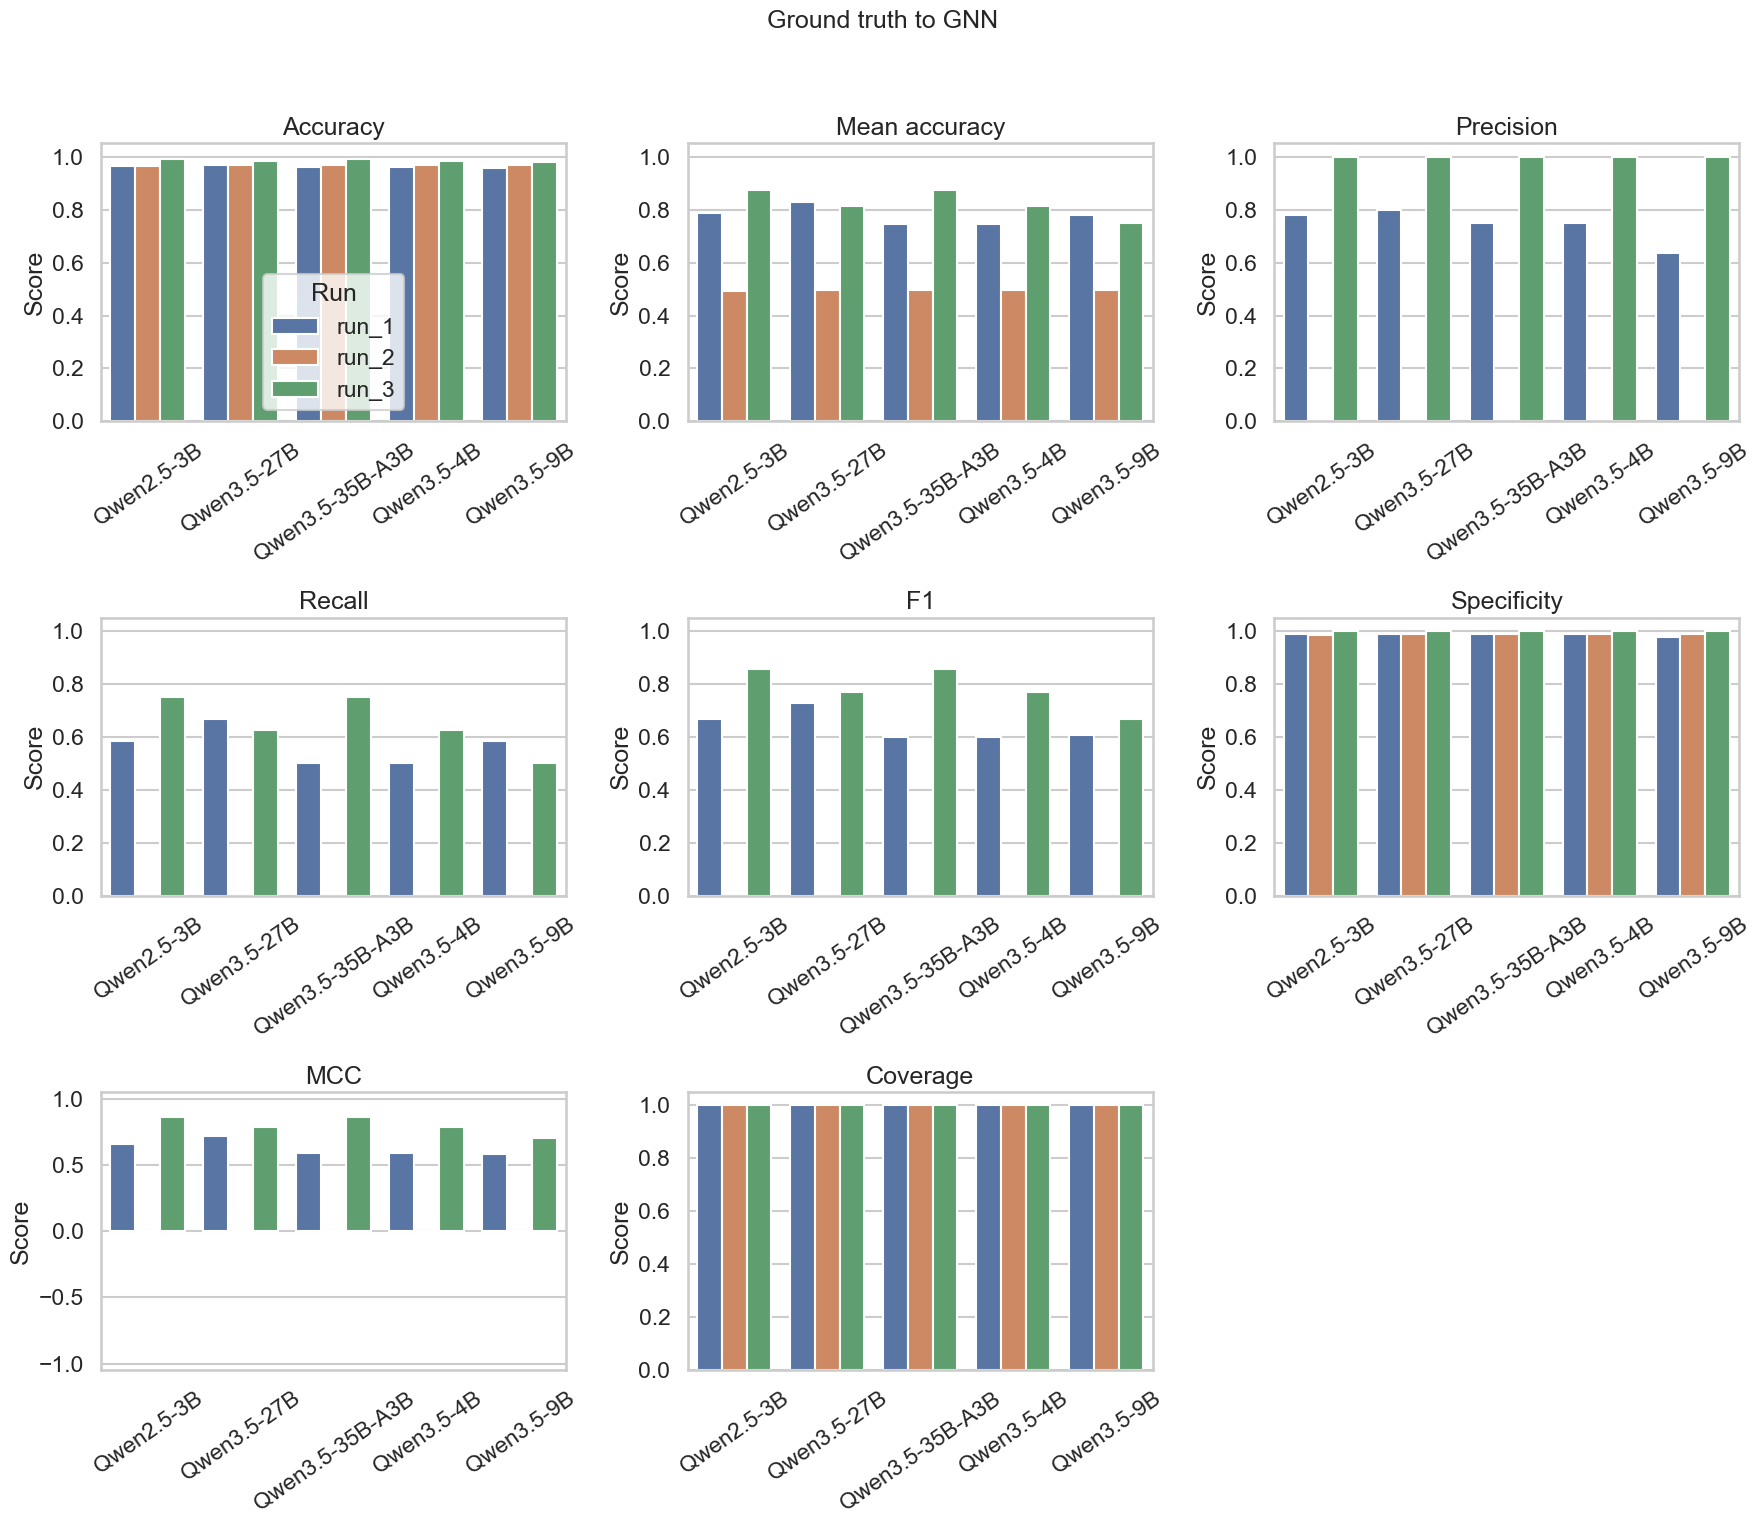

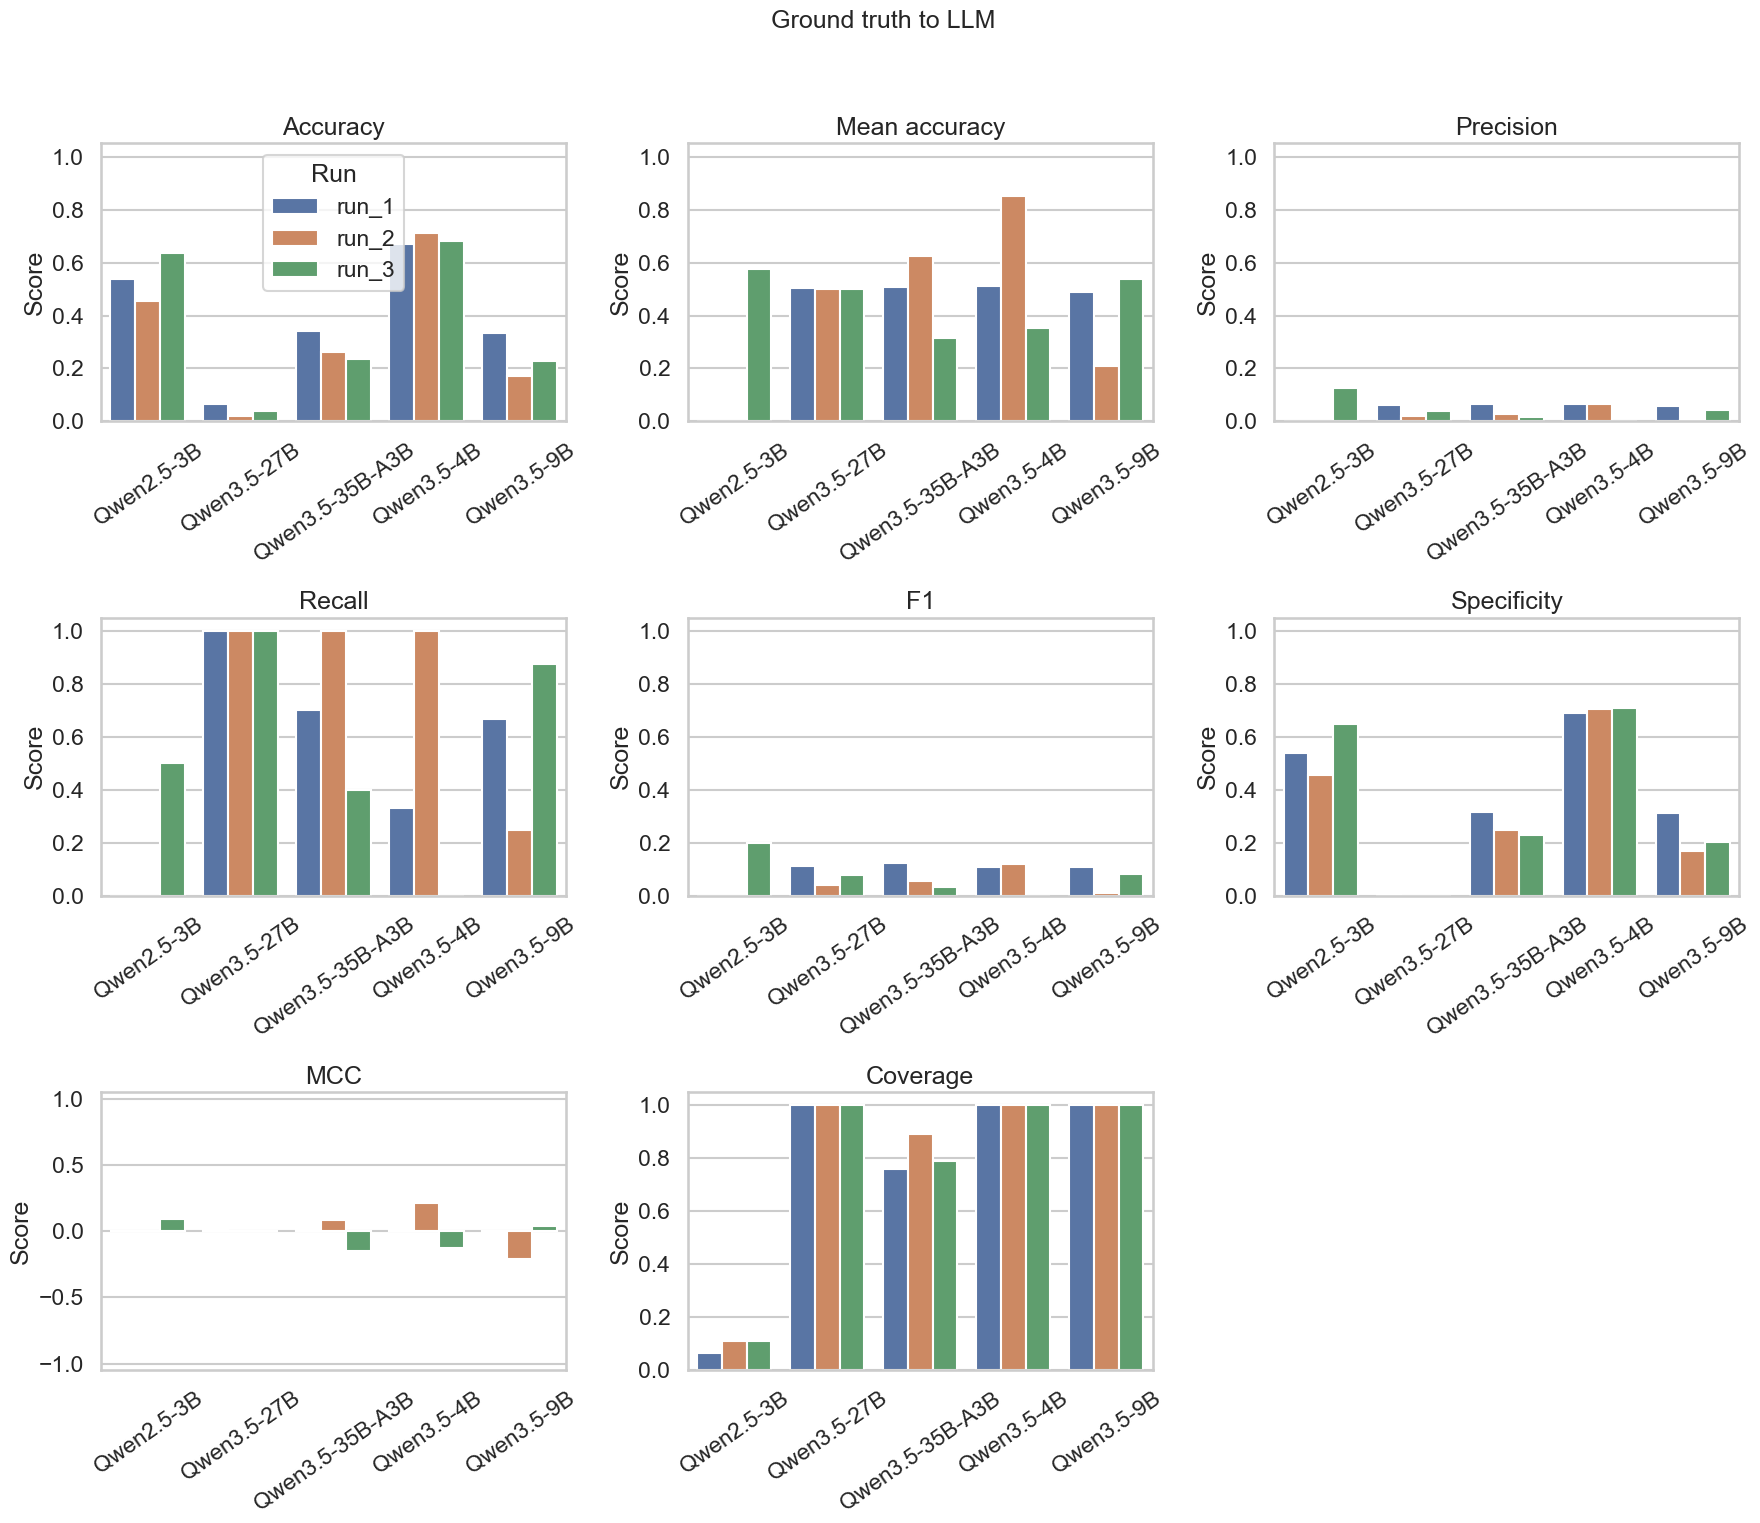

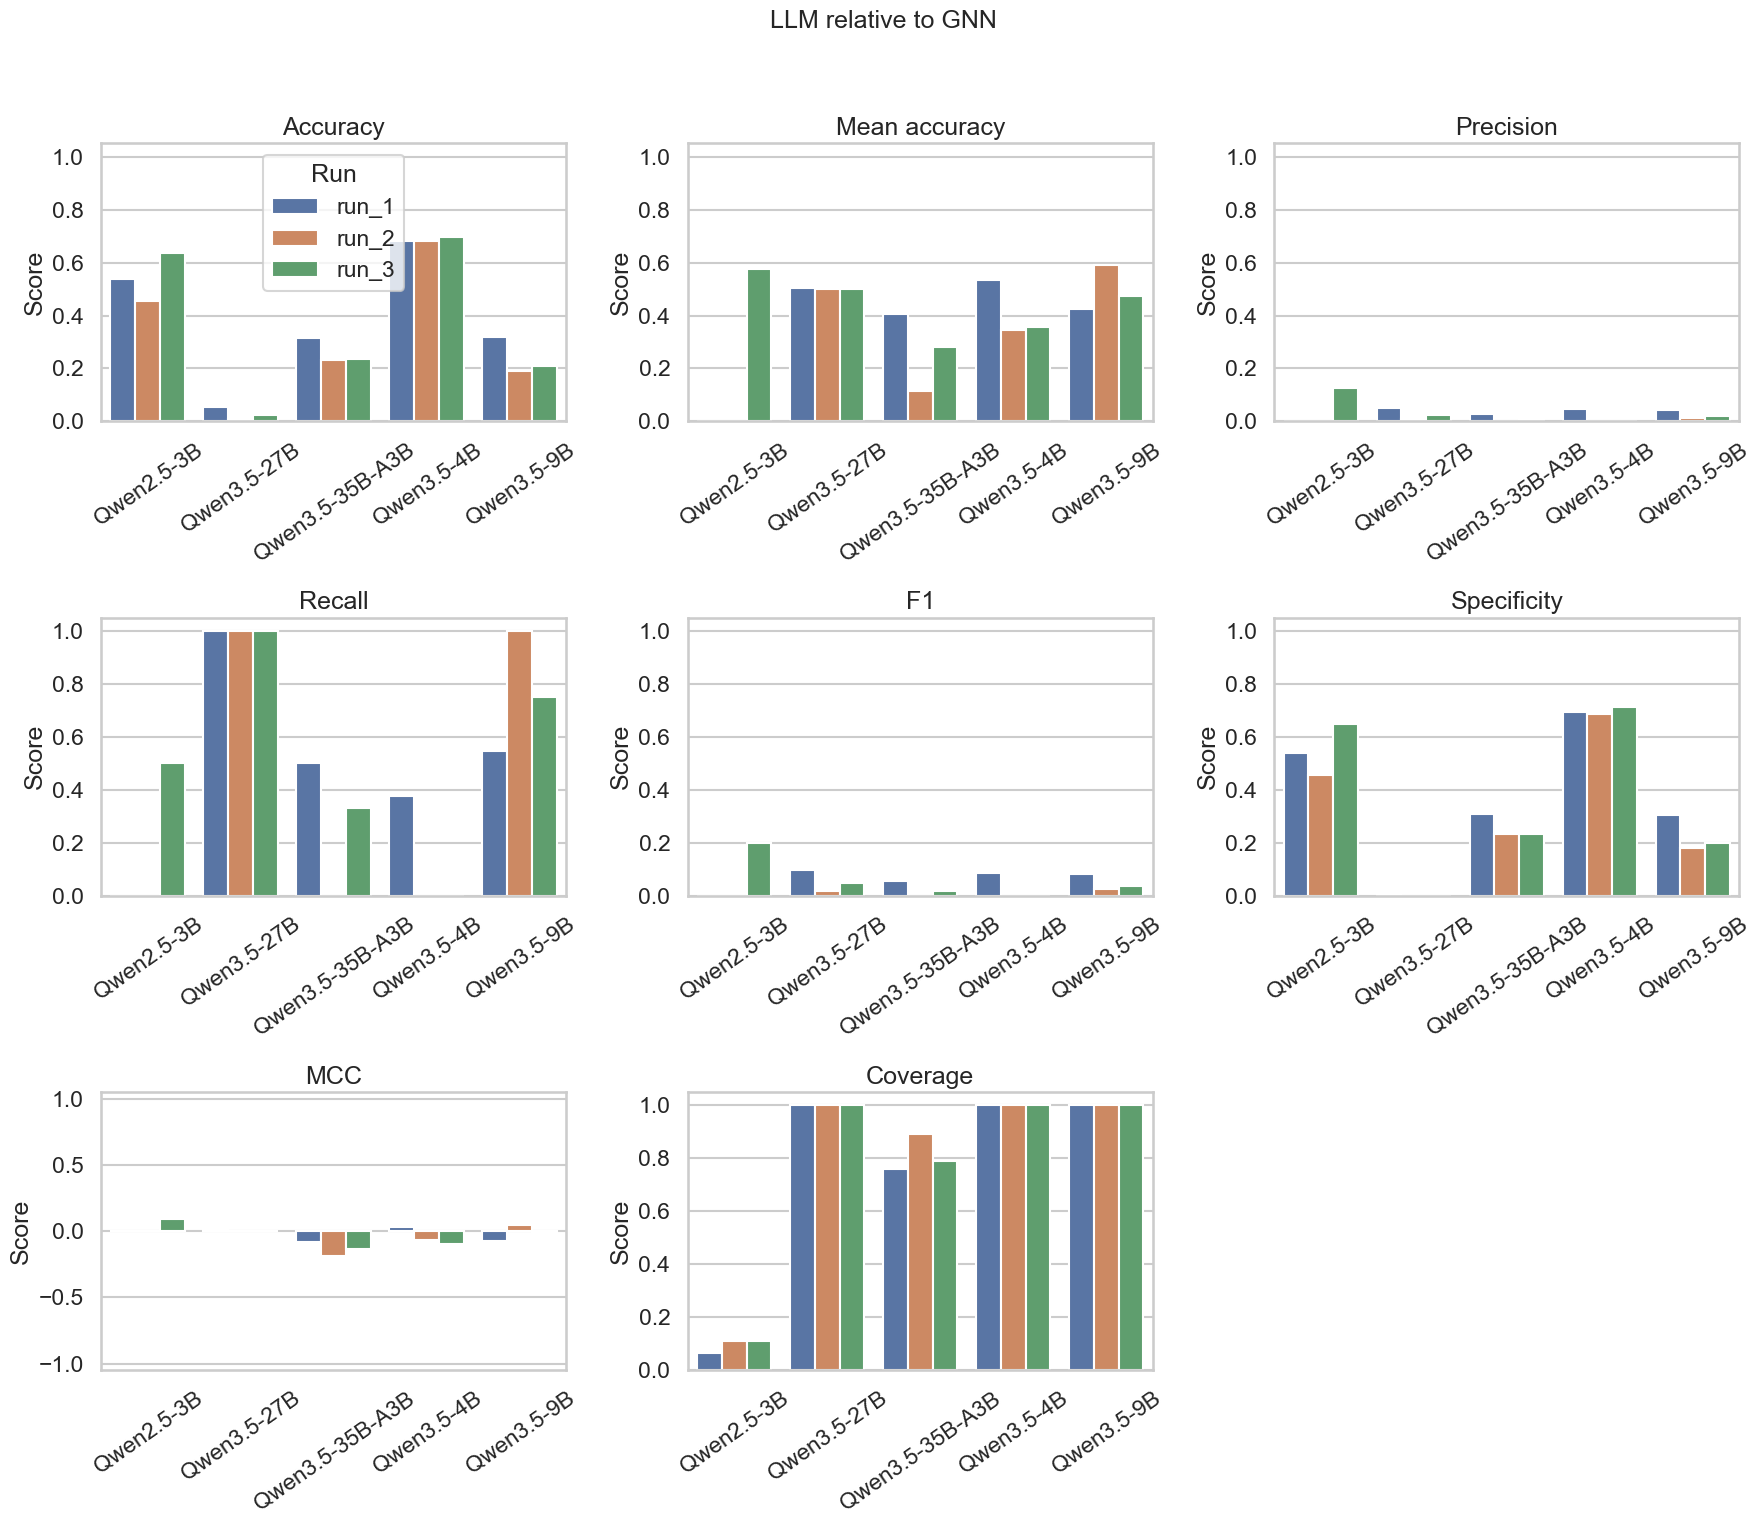

In [ ]:
selected_runs = DEFAULT_SELECTED_RUNS
selected_models = DEFAULT_SELECTED_MODELS

results_df = load_selected_runs(SNELLIUS_ROOT, selected_runs=selected_runs, selected_models=selected_models)
if results_df.empty:
    raise FileNotFoundError(f"No Snellius results found under {SNELLIUS_ROOT}")

metrics_df = build_metrics_frame(results_df)
summary_df = (
    metrics_df[metrics_df["metric"].isin(METRIC_ORDER)]
    .pivot_table(
        index=["run", "model_name", "comparison"],
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

print(f"Loaded {len(results_df)} rows from {results_df['run'].nunique()} run(s) and {results_df['model_name'].nunique()} model(s).")
display(summary_df.sort_values(["comparison", "run", "model_name"]))

all_figs = []
# Create one metrics figure per model, per comparison
save_metrics_dir = WORKSPACE_ROOT / "outputs" / "plots" / "metrics_by_model"
for comparison_name in COMPARISONS:
    figs = plot_metrics_split_by_model(metrics_df, comparison_name, selected_runs=selected_runs, selected_models=selected_models, save_dir=save_metrics_dir)
    all_figs.extend(figs)

# Confusion matrices (overall + per-model)
out_dir = WORKSPACE_ROOT / "outputs" / "plots" / "confusion_matrices"
cm_fig = plot_confusion_matrices(results_df, selected_runs=selected_runs, selected_models=selected_models, save_dir=out_dir)
if cm_fig is not None:
    all_figs.append(cm_fig)

# Render all open figures once
plt.show()

In [15]:
def _confusion_matrix_from_counts(tp, tn, fp, fn):
    return np.array([[tn, fp],
                     [fn, tp]])

def plot_confusion_matrices(results_df, selected_runs=None, selected_models=None, save_dir=None, figsize_per=4):
    df = results_df.copy()
    if selected_runs is not None:
        df = df[df["run"].isin(selected_runs)]
    if selected_models is not None:
        df = df[df["model_name"].isin(selected_models)]

    if df.empty:
        print("No data to plot.")
        return

    # Overall matrix (LLM as preds vs GNN as truth)
    overall_tp, overall_tn, overall_fp, overall_fn, overall_valid = confusion_counts(
        df["gnn_pred"].tolist(), df["llm_pred_parsed"].tolist()
    )
    overall_mat = _confusion_matrix_from_counts(overall_tp, overall_tn, overall_fp, overall_fn)

    n_models = df["model_name"].nunique()
    n_cols = min(4, n_models + 1)
    n_rows = int(np.ceil((n_models + 1) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per, n_rows * figsize_per))
    axes = np.array(axes).reshape(-1)

    # Plot overall first
    ax0 = axes[0]
    sns.heatmap(overall_mat, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax0)
    ax0.set_title("Overall (LLM preds vs GNN true)")
    ax0.set_xlabel("LLM prediction")
    ax0.set_ylabel("GNN true")
    ax0.set_xticklabels(["0", "1"])
    ax0.set_yticklabels(["0", "1"], rotation=0)

    # Per-model matrices
    for i, (model_name, group) in enumerate(df.groupby("model_name", sort=True, observed=False), start=1):
        tp, tn, fp, fn, valid = confusion_counts(group["gnn_pred"].tolist(), group["llm_pred_parsed"].tolist())
        mat = _confusion_matrix_from_counts(tp, tn, fp, fn)
        ax = axes[i]
        sns.heatmap(mat, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"{model_name}\n(valid={valid})")
        ax.set_xlabel("LLM prediction")
        ax.set_ylabel("GNN true")
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"], rotation=0)

    # Turn off any unused axes
    for j in range(n_models + 1, len(axes)):
        axes[j].set_axis_off()

    fig.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / "confusion_matrices_overall_and_per_model.png", dpi=200, bbox_inches="tight")
    return fig

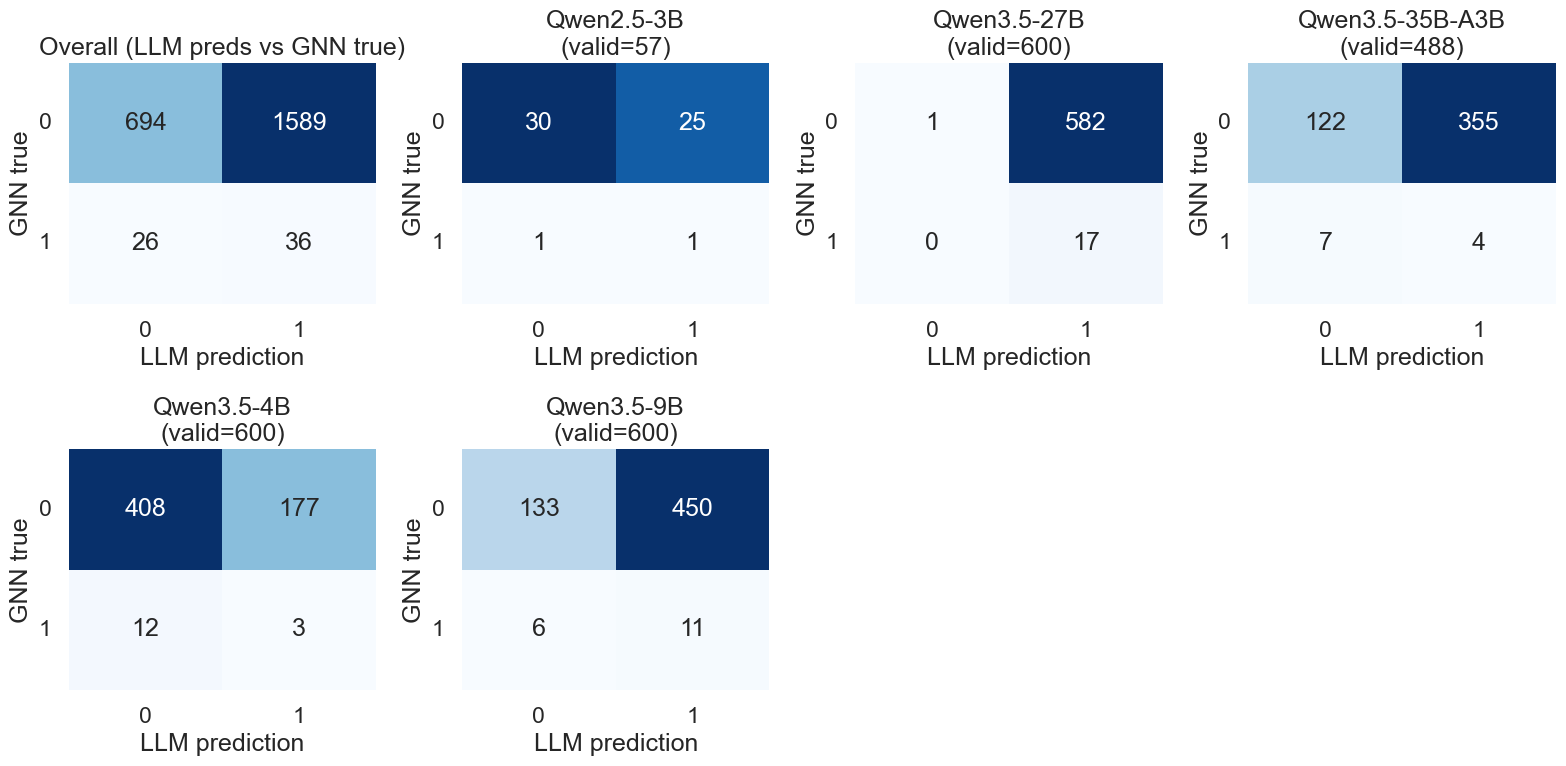

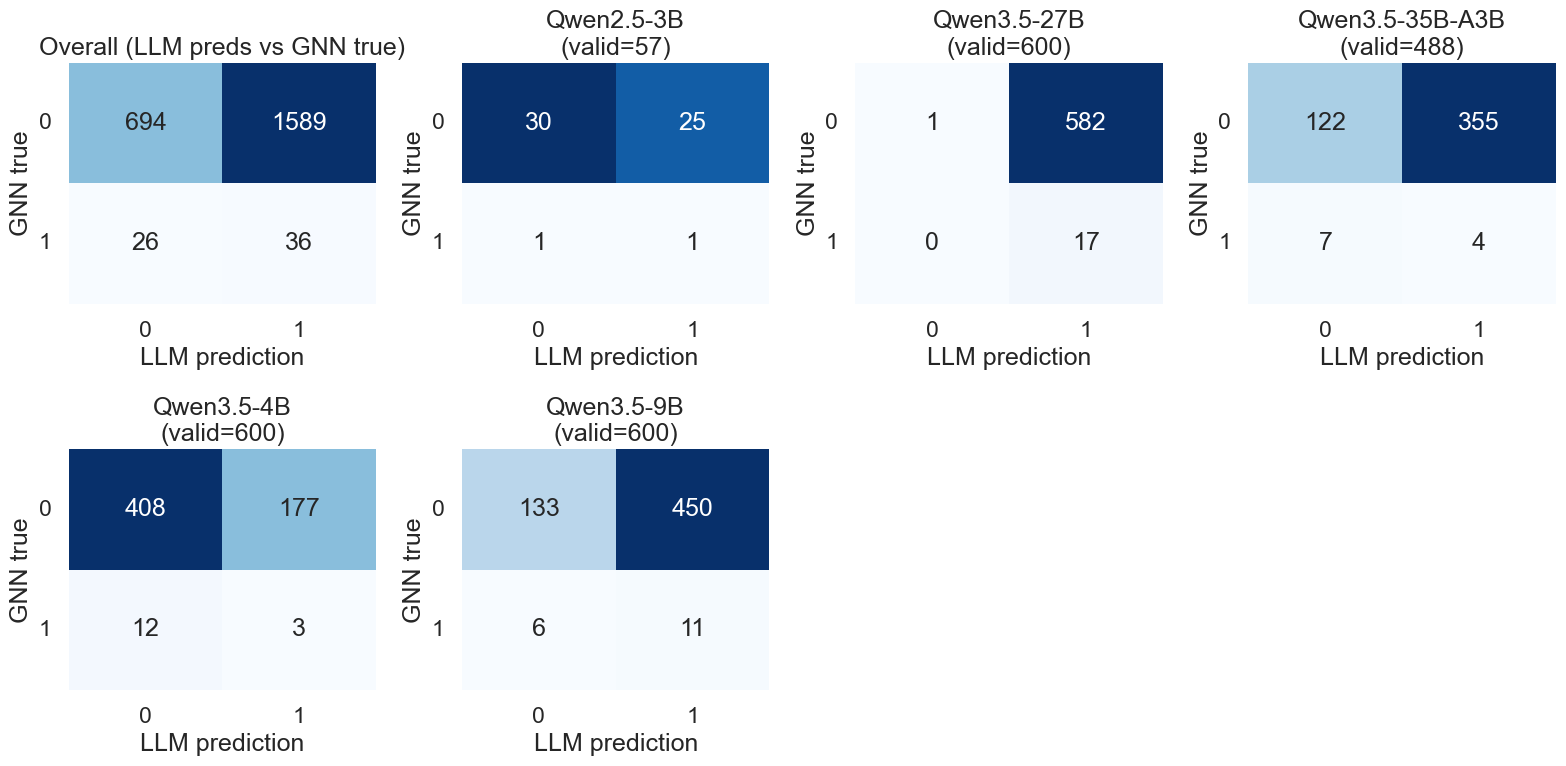

In [16]:
out_dir = WORKSPACE_ROOT / "outputs" / "plots" / "confusion_matrices"
plot_confusion_matrices(results_df, selected_runs=selected_runs, selected_models=selected_models, save_dir=out_dir)